### Simulation Investigation

Two variations of simulations

Original numerical instability is due to the compounding of drift terms across iterations 

First; given our KDE smoothed prior simulate level of sparsity that affects the simulation of our series across time

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from kernel_smoother import smooth_series, cv_block_size, mom_kde
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0).dropna()

trades=trades[trades.index < "2020-01-02 09:31:30"]
trades=trades[trades.index> "2020-01-02 09:30:30"]
trades['Trade_Price']=np.log(trades['Trade_Price'])
trades.index=pd.to_datetime(trades.index)

### Step 1; Generate Prior

Use volume data; normalizing index to difference in seconds

In [3]:
original_index=trades['Trade_Volume'].index

volume_index=[(i -original_index[0]).total_seconds() for i in original_index]
volume_prior=trades['Trade_Volume'].values

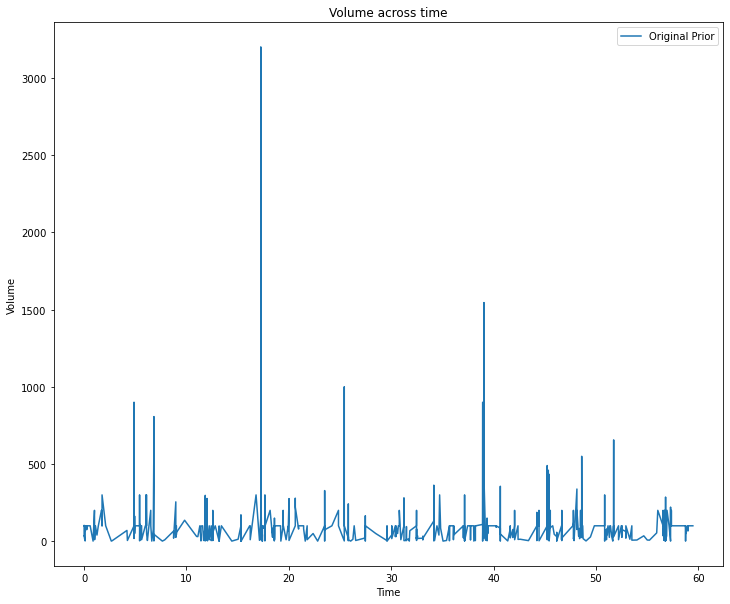

In [4]:
fig,ax=plt.subplots(figsize=(12,10))

plt.title("Volume across time")
plt.ylabel("Volume")
plt.xlabel("Time")
plt.plot(volume_index,volume_prior,label="Original Prior")
plt.legend()

### Step 2; Given Prior Apply Kernel Smoothing

- Apply Kernel smoothing across our penalty specifically
    - Gaussian Kernels using Scott's/ Silverman for bandwidth estimation
    - Robustness corrections (MOM)


In [5]:
kde_smooth,optimal_bw=smooth_series(volume_prior,volume_index)

In [6]:
block_params=np.arange(1,100,10)
optimal_mom_kde_bw,optimal_mse=cv_block_size(volume_prior,kde_smooth,volume_prior,optimal_bw,block_params,True)

 MSE for 1 blocks is 20558818.15
 MSE for 11 blocks is 20676213.7
 MSE for 21 blocks is 20700100.92
 MSE for 31 blocks is 20711744.52
 MSE for 41 blocks is 20699104.79
 MSE for 51 blocks is 20705142.89
 MSE for 61 blocks is 20712567.33
 MSE for 71 blocks is 20703162.4
 MSE for 81 blocks is 20705160.05
 MSE for 91 blocks is 20706933.58


In [7]:
optimal_mom_kde=mom_kde(kde_smooth,volume_index,optimal_mom_kde_bw,optimal_bw)

def min_max_norm(series):
    return (series-np.min(series))/(np.max(series)-np.min(series))

optimal_mom_kde_norm=min_max_norm(optimal_mom_kde)

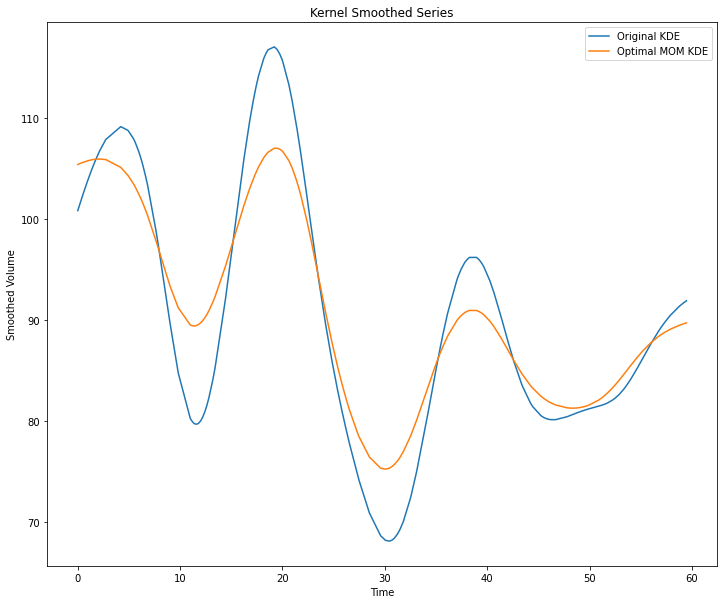

In [8]:
fig,ax=plt.subplots(figsize=(12,10))

plt.title("Kernel Smoothed Series")
plt.ylabel("Smoothed Volume")
plt.xlabel("Time")
plt.plot(volume_index,kde_smooth,label="Original KDE")
plt.plot(volume_index,optimal_mom_kde,label="Optimal MOM KDE")
plt.legend()

### Step 3; Sample Exponential distribution scaled by prior for sparsity enforcing param

In [9]:
def sample_from_prior(smooth_prior):
    """ Sample variance process given smoothed prior
    """
    samples=[]
    for x_i in smooth_prior:
        scale=2/(x_i**2)
        s_i=(x_i/2)*np.random.exponential(scale=scale)
        
        samples.append(s_i)
    
    return samples

In [10]:
sparse_samples=sample_from_prior(optimal_mom_kde)

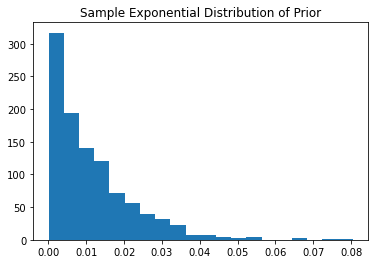

In [11]:
plt.title("Sample Exponential Distribution of Prior")
bins=plt.hist(sparse_samples,bins=20)

### Step 4 ; Sample $X_t$ given previous $X_i$ and laplace scale on variance

- Issue in sampling with numerical overflow -> Fixed by correctly accounting for series trend
- Specifically small variance gives our large oscillations in x values


In [14]:
def sample_price_series(sparse_params,variance=1,init=0):
    """ Sample price series by given sparse series representing discrete variance process across time
    """
    
    obs=[]
    obs.append(0)
    obs.append(0)
    for count,param in enumerate(sparse_params):
        mu=2*obs[count-1]-obs[count-2]

        scale=np.sqrt(param)*variance

        sample=np.random.normal(loc=mu,scale=scale,size=1)[0]
        
        obs.append(-1*(sample-mu) )
    
    obs=np.cumsum(np.array(obs))+init

    return obs

In [34]:
price_series=sample_price_series(sparse_samples,variance=1,init=50)

Text(0.5, 1.0, 'Simulated Path')

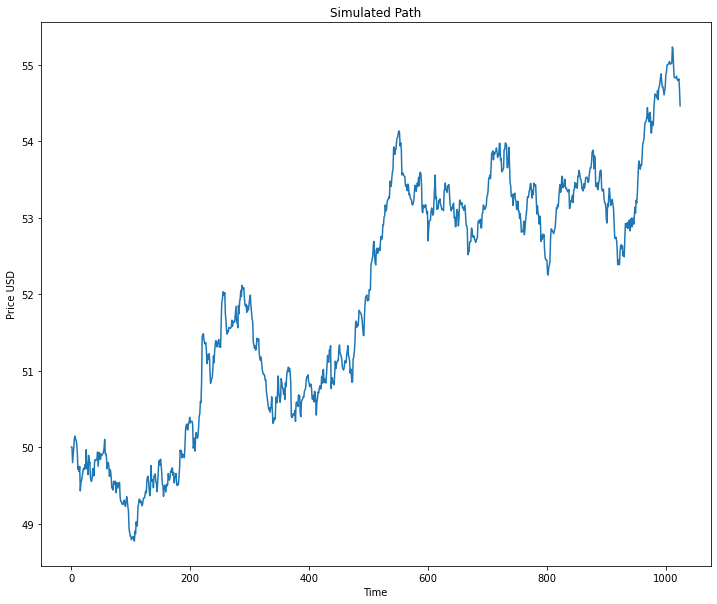

In [35]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(price_series)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path")

Take cumulative product; scale by constant  

In [41]:
trend_filter_series,status,D=l1tf_adaptive_ir(price_series.reshape(-1,1),lambda_p=50)

pobj1: [[4.67044515e+10]], pobj2: [[5579.05482238]], dobj: [[0.]], gap: [[5579.05482238]]
pobj1: [[3.34588614e+18]], pobj2: [[399.92814243]], dobj: [[5.52839592]], gap: [[394.3997465]]
pobj1: [[2.3164146e+17]], pobj2: [[124.207162]], dobj: [[12.65352527]], gap: [[111.55363673]]
pobj1: [[4.58610077e+16]], pobj2: [[68.66399733]], dobj: [[18.88775673]], gap: [[49.7762406]]
pobj1: [[2.07109551e+16]], pobj2: [[54.45802122]], dobj: [[24.69368335]], gap: [[29.76433787]]
pobj1: [[6.03008052e+16]], pobj2: [[52.67076082]], dobj: [[26.11543546]], gap: [[26.55532536]]
pobj1: [[1.6024261e+17]], pobj2: [[51.37641796]], dobj: [[27.119473]], gap: [[24.25694495]]
pobj1: [[2.18889977e+17]], pobj2: [[49.56918409]], dobj: [[28.27866691]], gap: [[21.29051718]]
pobj1: [[2.92923044e+17]], pobj2: [[48.1091401]], dobj: [[28.96505528]], gap: [[19.14408483]]
pobj1: [[3.80588241e+17]], pobj2: [[47.13334596]], dobj: [[29.62907179]], gap: [[17.50427417]]
pobj1: [[2.21360399e+16]], pobj2: [[45.49743225]], dobj: [[30

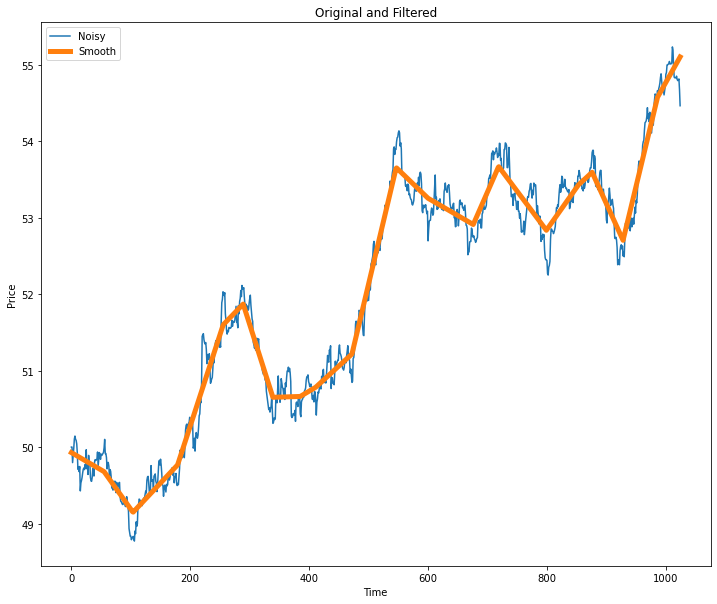

In [42]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(price_series,label='Noisy')
plt.plot(trend_filter_series,label='Smooth',lw=5)
plt.title("Original and Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Extract Changepoints

Changepoints in the underlying trend can be extracted via matrix multiplication of second difference matrix

In [43]:
def extract_cp(smooth,difference_order=2,threshold=1e-8):
    """ Extract changepoints via difference operator 
    """
    diff_mat=Dmat(len(smooth),2).todense()
    diff=np.dot(diff_mat,smooth).reshape(1,-1)[0]
    
    x,y,index=np.where([abs(diff)>threshold])
    return index

In [44]:
changepoints=extract_cp(trend_filter_series)

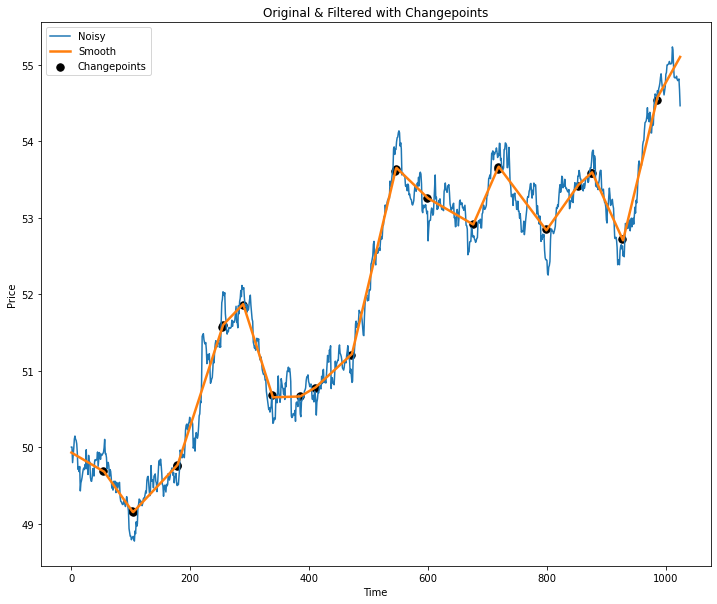

In [46]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(price_series,label='Noisy')
plt.plot(trend_filter_series,label='Smooth',lw=2.5)
plt.scatter(changepoints,trend_filter_series[changepoints],color='black',s=55,label='Changepoints')
plt.title("Original & Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Simulation Version 2

Simulate change points near location of volume; applying estimator to detect changepoints from there |

In [22]:
def find_max(prior,count):
    """ Find max n values of a series 
    """
    series=dict(zip(np.arange(0,len(prior)),prior))
    sorted_series=sorted( series.items(), key=lambda x:x[1],reverse=True)[:count]
    sorted_series=sorted(sorted_series, key=lambda x:x[0])
    
    indices=[i[0] for i in sorted_series]
    values=[i[1] for i in sorted_series]
    
    return sorted(np.array(indices)),np.array(values)
    
indices,values=find_max(volume_prior,50)


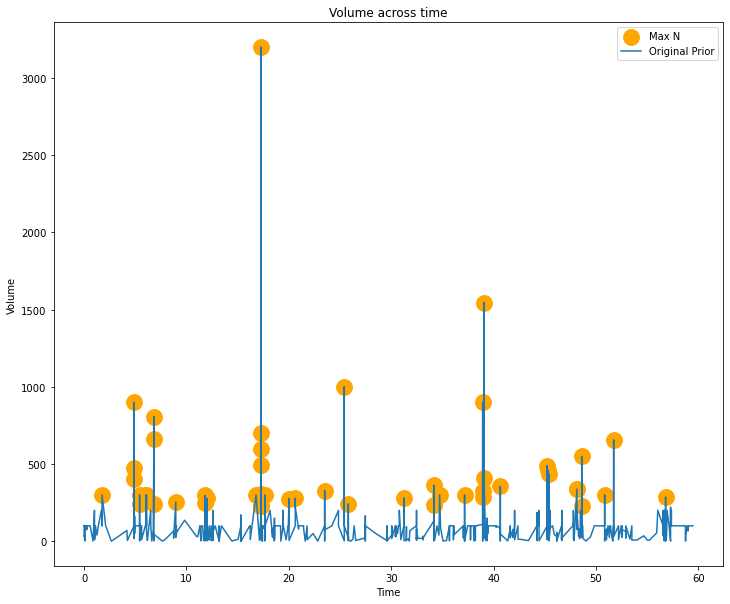

In [23]:
fig,ax=plt.subplots(figsize=(12,10))

plt.title("Volume across time")
plt.ylabel("Volume")
plt.xlabel("Time")
plt.scatter(np.array(volume_index)[indices],values,color='orange', label='Max N',s=250)
plt.plot(volume_index,volume_prior,label="Original Prior")
plt.legend()

In [47]:
def simulate_from_prior(changepoints,variance=0.05,N=1000,init=0,scale_factor=10e-5):
    """ Simulate price process as piecewise linear between selected changepoints; scaling distance btwn consecutive cp
    """
    
    increment,counter=0,0
    x0,x1=0,0
    diff=x1-x0
    samples=[]
    samples.append(x0)
    samples.append(x1)
    lb=0
    
    for point in range(0,N):
        
        while point<counter:
            point+=1
            continue
            
        if counter>N or  increment>=len(changepoints):
            break
       
        if  point==changepoints[increment]:
            increment+=1
            mu=2*samples[point-1]-samples[point-2] # location
            scale=variance
            sample=np.random.normal(loc=mu,scale=scale,size=1)[0]
            
            # compute difference; add to sample
            diff=sample-mu
            samples.append(-1*diff)
            
            
        else:
          
            # compute vector between consecutive cp
            ub=changepoints[increment]
            step=ub-lb
            lb=changepoints[increment]
            
            sequence=list(samples[-1]+scale_factor*diff*np.arange(0,step-1,1))
           
            for i in sequence:
                samples.append(i)
            
            counter+=step
        
    samples=np.cumsum(np.array(samples))+init
    return samples
    

In [48]:
price_series_vol=simulate_from_prior(indices,init=50)


Text(0.5, 1.0, 'Simulated Path')

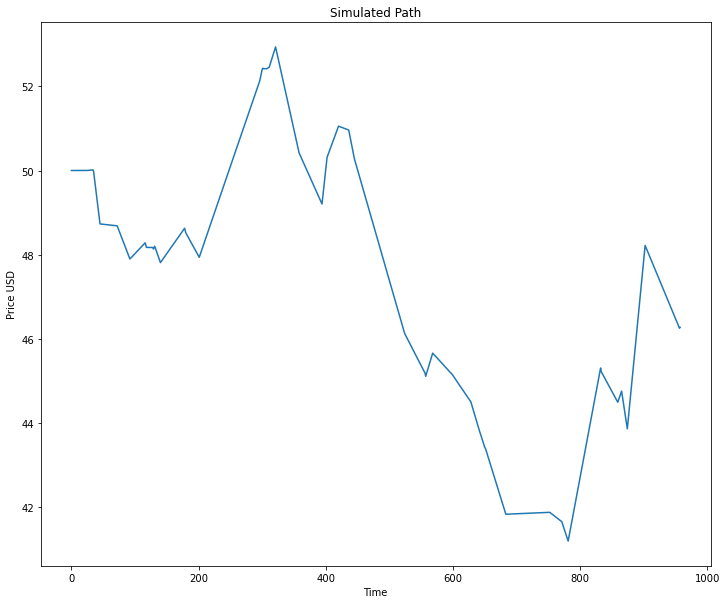

In [49]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(price_series_vol)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path")

In [50]:
trend_filter_series,status,D=l1tf_adaptive_ir(price_series_vol.reshape(-1,1),lambda_p=1000)

pobj1: [[4.37540336e+11]], pobj2: [[3154.16785589]], dobj: [[0.]], gap: [[3154.16785589]]
pobj1: [[6.90908742e+17]], pobj2: [[1867.89450788]], dobj: [[6.82873007]], gap: [[1861.06577781]]
pobj1: [[4.26674248e+16]], pobj2: [[1078.96004678]], dobj: [[62.78437943]], gap: [[1016.17566735]]
pobj1: [[8.15751004e+15]], pobj2: [[674.6311384]], dobj: [[141.56656798]], gap: [[533.06457042]]
pobj1: [[3.30538561e+15]], pobj2: [[502.82700761]], dobj: [[206.16063408]], gap: [[296.66637353]]
pobj1: [[5.2747757e+15]], pobj2: [[455.83273805]], dobj: [[230.52213]], gap: [[225.31060805]]
pobj1: [[6.97944883e+15]], pobj2: [[424.86399595]], dobj: [[242.10542754]], gap: [[182.7585684]]
pobj1: [[3.59728536e+14]], pobj2: [[393.31624012]], dobj: [[254.43053893]], gap: [[138.88570119]]
pobj1: [[6.31694174e+14]], pobj2: [[379.88765653]], dobj: [[266.96080203]], gap: [[112.9268545]]
pobj1: [[9.26532708e+14]], pobj2: [[370.68364269]], dobj: [[274.5230977]], gap: [[96.16054498]]
pobj1: [[6.17979162e+13]], pobj2: [[

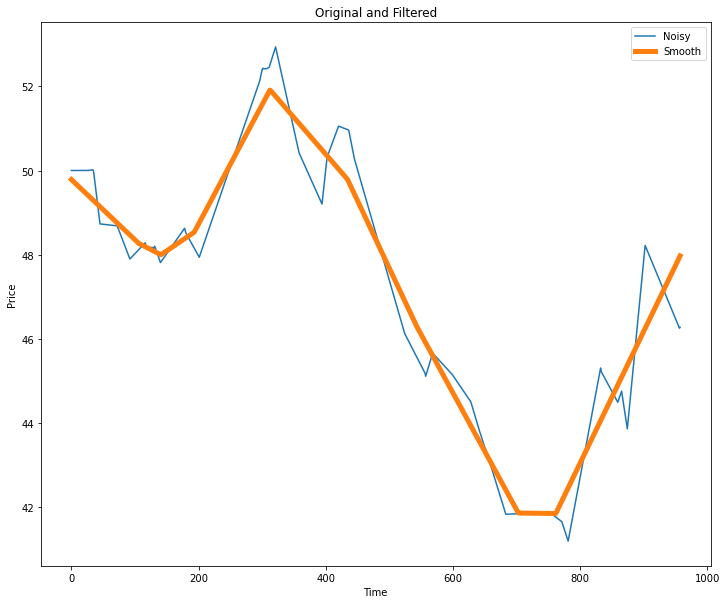

In [51]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(price_series_vol,label='Noisy')
plt.plot(trend_filter_series,label='Smooth',lw=5)
plt.title("Original and Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

In [52]:
changepoints=extract_cp(trend_filter_series)

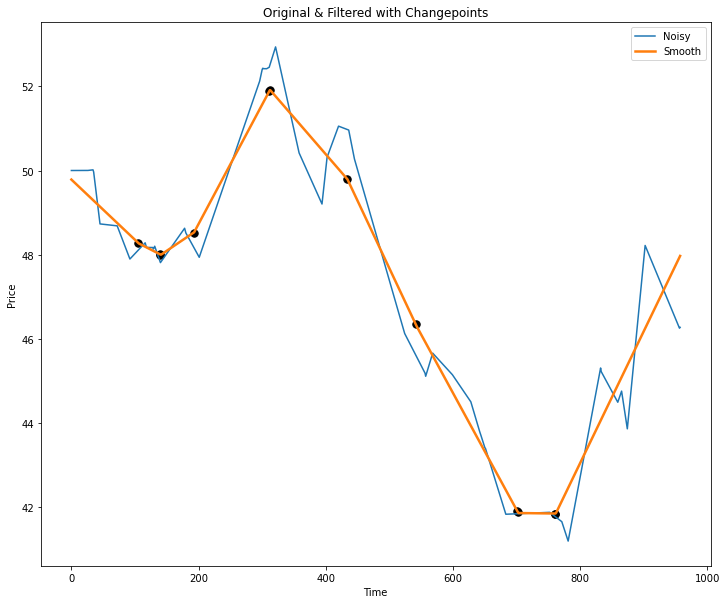

In [53]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(price_series_vol,label='Noisy')
plt.plot(trend_filter_series,label='Smooth',lw=2.5)
plt.scatter(changepoints,trend_filter_series[changepoints],color='black',s=55)
plt.title("Original & Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()